In [1]:
import pandas as pd
import numpy as np
import duckdb
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100
sns.set_theme(style="whitegrid", palette="muted")

print("Imports successful")

Imports successful


In [2]:
rfm = pd.read_csv("../data/processed/rfm_scored.csv")
print(f"RFM table shape: {rfm.shape}")
rfm.head()

RFM table shape: (3920, 10)


,CustomerID,recency,frequency,monetary,r_score,f_score,m_score,rfm_segment,rfm_score,segment
0,13784,10,11,2462.79,5,5,5,555,5.0,Champions
1,15750,3,8,2463.05,5,5,5,555,5.0,Champions
2,14766,9,6,2473.37,5,5,5,555,5.0,Champions
3,17188,12,7,2474.23,5,5,5,555,5.0,Champions
4,17682,11,6,2474.33,5,5,5,555,5.0,Champions


## Phase 2: Prediction Pipeline
### Step 1: Feature Engineering + Scaling

In [3]:
# Using log transform first to handle skewness we saw in distributions
rfm_model = rfm[["CustomerID", "recency", "frequency", "monetary"]].copy()

rfm_model["log_recency"]   = np.log1p(rfm_model["recency"])
rfm_model["log_frequency"] = np.log1p(rfm_model["frequency"])
rfm_model["log_monetary"]  = np.log1p(rfm_model["monetary"])

# Scale to 0-1
features = ["log_recency", "log_frequency", "log_monetary"]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(rfm_model[features])

print(f"Feature matrix shape: {X_scaled.shape}")
print(f"Mean per feature: {X_scaled.mean(axis=0).round(3)}")
print(f"Std per feature:  {X_scaled.std(axis=0).round(3)}")

Feature matrix shape: (3920, 3)
Mean per feature: [-0. -0.  0.]
Std per feature:  [1. 1. 1.]


k=2  inertia=5805.4  silhouette=0.4346
k=3  inertia=4328.5  silhouette=0.3406
k=4  inertia=3490.4  silhouette=0.3357
k=5  inertia=2905.5  silhouette=0.3206
k=6  inertia=2519.9  silhouette=0.3139
k=7  inertia=2238.3  silhouette=0.3083
k=8  inertia=2052.4  silhouette=0.3059
k=9  inertia=1888.2  silhouette=0.2864
k=10  inertia=1748.5  silhouette=0.2808


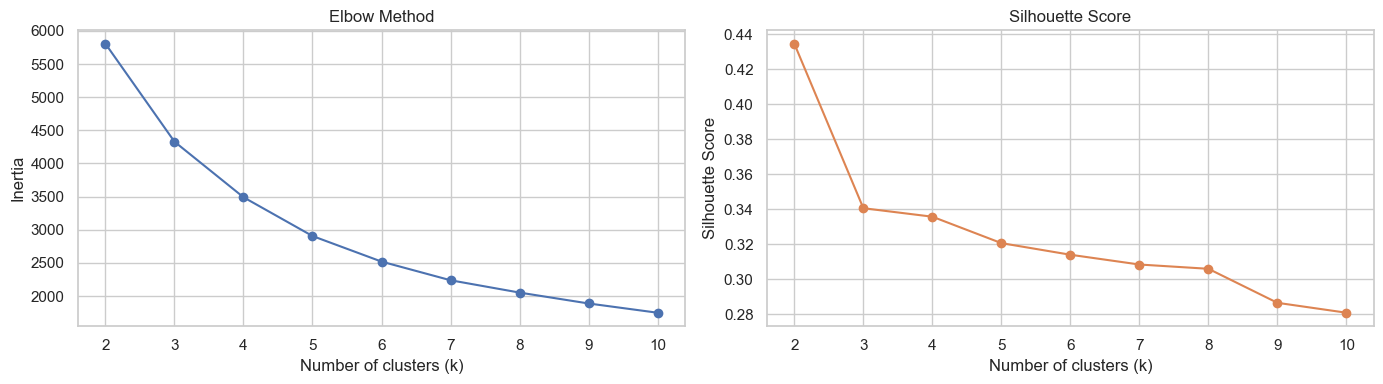

In [4]:
# Find optimal K with elbow + silhouette
inertias = []
silhouettes = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    print(f"k={k}  inertia={km.inertia_:.1f}  silhouette={silhouette_score(X_scaled, labels):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(k_range, inertias, marker="o", color="#4C72B0")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")

axes[1].plot(k_range, silhouettes, marker="o", color="#DD8452")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

In [5]:
# Train final K-Means model with k=4
K = 4

kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
rfm_model["cluster"] = kmeans.fit_predict(X_scaled)

print(f"Cluster sizes:")
print(rfm_model["cluster"].value_counts().sort_index())

Cluster sizes:
cluster
0     636
1    1411
2    1050
3     823
Name: count, dtype: int64


In [6]:
# Analyze clusters
cluster_summary = rfm_model.groupby("cluster").agg(
    num_customers = ("CustomerID", "count"),
    avg_recency   = ("recency", "mean"),
    avg_frequency = ("frequency", "mean"),
    avg_monetary  = ("monetary", "mean")
).round(2)

print(cluster_summary)

         num_customers  avg_recency  avg_frequency  avg_monetary
cluster                                                         
0                  636        11.86          13.60       7192.10
1                 1411       190.66           1.35        342.28
2                 1050        64.86           4.29       1749.00
3                  823        22.94           1.94        475.63


In [11]:
# Label clusters based on their characteristics
# assigning labels after seeing the summary above
# Rank clusters by avg_monetary to assign labels reliably
cluster_ranked = cluster_summary["avg_monetary"].rank(ascending=False).astype(int)

cluster_label_map = {}
for cluster_id, rank in cluster_ranked.items():
    if rank == 1:
        cluster_label_map[cluster_id] = "Champions"
    elif rank == 2:
        cluster_label_map[cluster_id] = "Loyal Customers"
    elif rank == 3:
        cluster_label_map[cluster_id] = "At Risk"
    else:
        cluster_label_map[cluster_id] = "Lost"

print("Cluster label map:", cluster_label_map)
rfm_model["cluster_label"] = rfm_model["cluster"].map(cluster_label_map)
print(rfm_model["cluster_label"].value_counts())

Cluster label map: {0: 'Champions', 1: 'Lost', 2: 'Loyal Customers', 3: 'At Risk'}
cluster_label
Lost               1411
Loyal Customers    1050
At Risk             823
Champions           636
Name: count, dtype: int64


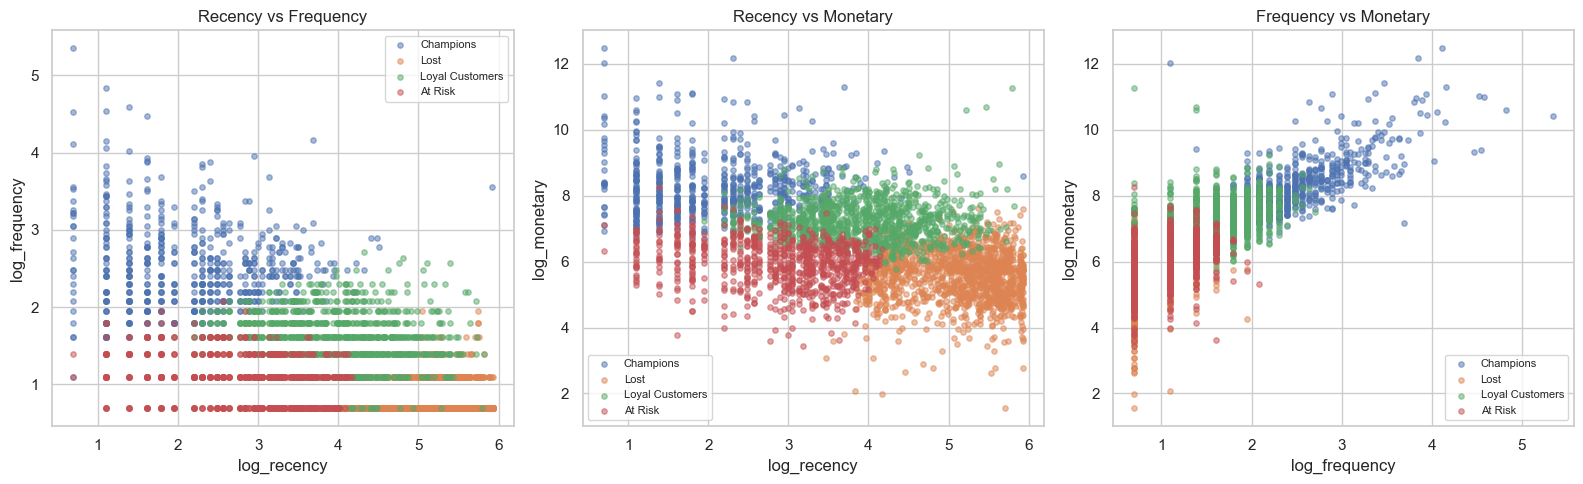

In [12]:
# Visualize clusters in 3D RFM space
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

pairs = [
    ("log_recency",   "log_frequency", "Recency vs Frequency"),
    ("log_recency",   "log_monetary",  "Recency vs Monetary"),
    ("log_frequency", "log_monetary",  "Frequency vs Monetary"),
]

colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

for ax, (x, y, title) in zip(axes, pairs):
    for i, label in cluster_label_map.items():
        mask = rfm_model["cluster"] == i
        ax.scatter(
            rfm_model.loc[mask, x],
            rfm_model.loc[mask, y],
            label=label, alpha=0.5, s=15, color=colors[i]
        )
    ax.set_title(title)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

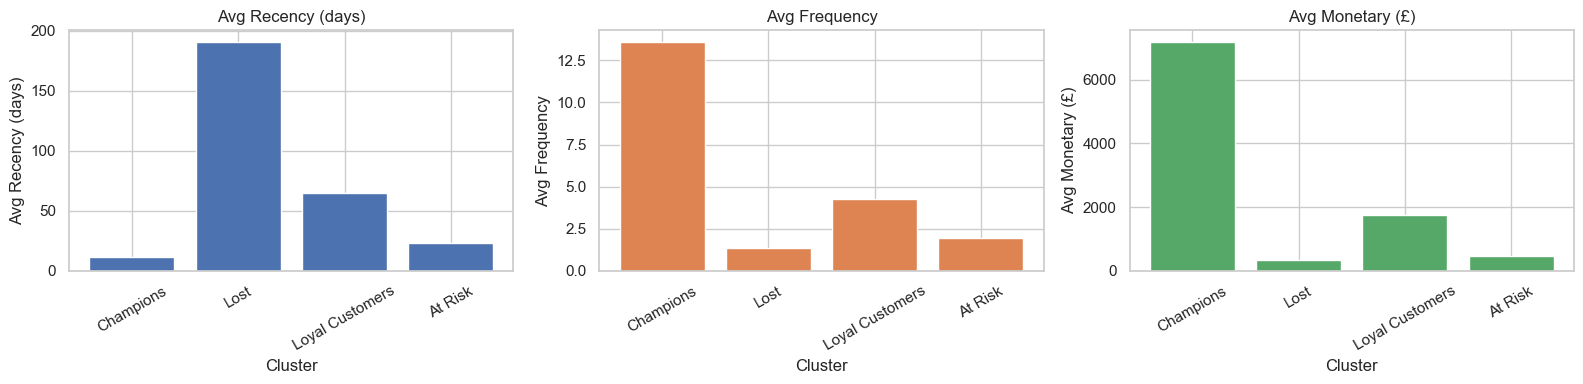

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

metrics = [
    ("avg_recency",   "Avg Recency (days)",  "#4C72B0"),
    ("avg_frequency", "Avg Frequency",       "#DD8452"),
    ("avg_monetary",  "Avg Monetary (£)",    "#55A868"),
]

for ax, (metric, ylabel, color) in zip(axes, metrics):
    labels = [cluster_label_map[i] for i in cluster_summary.index]
    ax.bar(labels, cluster_summary[metric], color=color, edgecolor="white")
    ax.set_title(ylabel)
    ax.set_xlabel("Cluster")
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

In [14]:
# Save model artifacts
os.makedirs("../src/models", exist_ok=True)

# Save kmeans model and scaler
joblib.dump(kmeans, "../src/models/kmeans_k4.pkl")
joblib.dump(scaler, "../src/models/scaler.pkl")

# Save cluster label map
import json
with open("../src/models/cluster_label_map.json", "w") as f:
    json.dump({str(k): v for k, v in cluster_label_map.items()}, f)

# Save final rfm with cluster labels
rfm_final = rfm_model.merge(
    rfm[["CustomerID", "recency", "frequency", "monetary", "rfm_score", "segment"]],
    on=["CustomerID", "recency", "frequency", "monetary"],
    how="left"
)
rfm_final.to_csv("../data/processed/rfm_clustered.csv", index=False)

print("Saved:")
print("  src/models/kmeans_k4.pkl")
print("  src/models/scaler.pkl")
print("  src/models/cluster_label_map.json")
print("  data/processed/rfm_clustered.csv")

Saved:
  src/models/kmeans_k4.pkl
  src/models/scaler.pkl
  src/models/cluster_label_map.json
  data/processed/rfm_clustered.csv


In [16]:
df_uk = pd.read_csv("../data/processed/transactions_clean.csv", parse_dates=["InvoiceDate"])
print(f"Loaded transactions: {df_uk.shape}")

Loaded transactions: (349203, 9)


In [17]:
# Build the reusable pipeline function
def predict_segments(transactions_df, snapshot_date=None):
    """
    Takes a raw transactions dataframe and returns RFM + cluster labels.
    
    Args:
        transactions_df: DataFrame with columns
                         [CustomerID, InvoiceNo, InvoiceDate, Revenue]
        snapshot_date:   Reference date for recency calculation.
                         Defaults to 1 day after last transaction.
    Returns:
        DataFrame with CustomerID, recency, frequency, monetary,
        cluster, cluster_label
    """
    if snapshot_date is None:
        snapshot_date = transactions_df["InvoiceDate"].max() + pd.Timedelta(days=1)

    # Build RFM
    rfm_new = transactions_df.groupby("CustomerID").agg(
        recency   = ("InvoiceDate",  lambda x: (snapshot_date - x.max()).days),
        frequency = ("InvoiceNo",    "nunique"),
        monetary  = ("Revenue",      "sum")
    ).reset_index()

    # Log transform + scale
    rfm_new["log_recency"]   = np.log1p(rfm_new["recency"])
    rfm_new["log_frequency"] = np.log1p(rfm_new["frequency"])
    rfm_new["log_monetary"]  = np.log1p(rfm_new["monetary"])

    features = ["log_recency", "log_frequency", "log_monetary"]
    X = scaler.transform(rfm_new[features])

    # Predict cluster
    rfm_new["cluster"]       = kmeans.predict(X)
    rfm_new["cluster_label"] = rfm_new["cluster"].map(cluster_label_map)

    return rfm_new.drop(columns=["log_recency", "log_frequency", "log_monetary"])


# Test it on our existing data
result = predict_segments(df_uk)
print(result.shape)
print(result["cluster_label"].value_counts())
result.head()

(3920, 6)
cluster_label
Lost               1404
Loyal Customers    1044
At Risk             831
Champions           641
Name: count, dtype: int64


,CustomerID,recency,frequency,monetary,cluster,cluster_label
0,12346,326,1,77183.60,2,Loyal Customers
1,12747,2,11,4196.01,0,Champions
2,12748,1,209,33053.19,0,Champions
3,12749,4,5,4090.88,0,Champions
4,12820,3,4,942.34,3,At Risk


In [18]:
# Write pipeline.py to src/
pipeline_code = '''import pandas as pd
import numpy as np
import joblib
import json
from pathlib import Path

MODEL_DIR = Path(__file__).parent / "models"

kmeans      = joblib.load(MODEL_DIR / "kmeans_k4.pkl")
scaler      = joblib.load(MODEL_DIR / "scaler.pkl")

with open(MODEL_DIR / "cluster_label_map.json") as f:
    raw = json.load(f)
    cluster_label_map = {int(k): v for k, v in raw.items()}


def predict_segments(transactions_df, snapshot_date=None):
    """
    Takes a raw transactions dataframe and returns RFM + cluster labels.

    Args:
        transactions_df: DataFrame with columns
                         [CustomerID, InvoiceNo, InvoiceDate, Revenue]
        snapshot_date:   Reference date for recency calculation.
                         Defaults to 1 day after last transaction.
    Returns:
        DataFrame with CustomerID, recency, frequency, monetary,
        cluster, cluster_label
    """
    if snapshot_date is None:
        snapshot_date = transactions_df["InvoiceDate"].max() + pd.Timedelta(days=1)

    rfm = transactions_df.groupby("CustomerID").agg(
        recency   = ("InvoiceDate",  lambda x: (snapshot_date - x.max()).days),
        frequency = ("InvoiceNo",    "nunique"),
        monetary  = ("Revenue",      "sum")
    ).reset_index()

    rfm["log_recency"]   = np.log1p(rfm["recency"])
    rfm["log_frequency"] = np.log1p(rfm["frequency"])
    rfm["log_monetary"]  = np.log1p(rfm["monetary"])

    features = ["log_recency", "log_frequency", "log_monetary"]
    X = scaler.transform(rfm[features])

    rfm["cluster"]       = kmeans.predict(X)
    rfm["cluster_label"] = rfm["cluster"].map(cluster_label_map)

    return rfm.drop(columns=["log_recency", "log_frequency", "log_monetary"])
'''

with open("../src/pipeline.py", "w") as f:
    f.write(pipeline_code)

print("src/pipeline.py written successfully")

src/pipeline.py written successfully


In [19]:
# Test importing it as a module
import sys
sys.path.append("../src")

from pipeline import predict_segments as predict_segments_module

result2 = predict_segments_module(df_uk)
print(result2["cluster_label"].value_counts())
print("Module import and prediction works correctly")

cluster_label
Lost               1404
Loyal Customers    1044
At Risk             831
Champions           641
Name: count, dtype: int64
Module import and prediction works correctly
